In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Gradient Descent with Numpy

In [2]:
df = pd.read_csv("day.csv")

The imported dataset contains the daily count of rental bikes between the years 2011 and 2012 in Capital bikeshare system, along with data on the weather, seasonal information, etc.

For this dataset, the target will be the count of rental bikes (cnt). The features that will be taken into account are the normalized temperature in degrees Celsius (temp), the normalized feeling temperature in degrees Celsius (atemp), the normalized humidity (hum), the wind speed (windspeed), whether if the day is a holiday or not (holiday), what season it was (season), whether the day was a working day (workingday) and what the weather was (weathersit).

In [3]:
features = ["temp","atemp","hum","windspeed","holiday","season","workingday","weathersit"]

X_raw = df[features].values #shape (731,8)
Y = df["cnt"].values    #shape (731,)

The dataset is split into a training set and a test set to evaluate the model. The split is 80/20 training/test. In order for the training set to be fair and avoid chronological biases, the elements added to it are selected at random. Z score normalization is also performed on the dataset in order to avoid favoring a specific direction when performing gradient descent.

It is worth noting that the normalization statistics (mean and standard deviation) are computed from the training set only, so not to have the test data influence the preprocessing.

In [4]:
np.random.seed(42)
idx = np.random.permutation(len(Y))

split = int(0.8*len(Y))

idx_train, idx_test = idx[:split], idx[split:]

X_train_raw, X_test_raw = X_raw[idx_train], X_raw[idx_test]
y_train, y_test = Y[idx_train], Y[idx_test]

mu = X_train_raw.mean(axis=0)
std = X_train_raw.std(axis=0)

X_train = (X_train_raw - mu)/(std + 1e-8)
X_test = (X_test_raw - mu)/(std + 1e-8)

A column of ones is added to the dataset to function as the y-intercept term.

In [5]:
X_train = np.hstack([np.ones((X_train.shape[0],1)),X_train])
X_test = np.hstack([np.ones((X_test.shape[0],1)),X_test])

At a first instance, only linear regression will be employed for learning. Thus, the hypothesis will be expressed simply as

$$h(X) = X\cdot\theta.$$

For a linear model, the cost function is defined as

$$J(\theta) = \frac{1}{2n}\sum_{i=1}^n \left(h_\theta(x^{(i)}) - y^{(i)}\right)^2. $$

In [6]:
def hypothesis(X,theta):
    return X@theta

def compute_cost(X,y,theta):
    n = len(y)
    errors = hypothesis(X,theta) - y
    return 1/(2*n)*np.dot(errors,errors)

Using the gradient descent algorithm, the update rule is

$$\theta_j := \theta_j + \alpha\frac{1}{n}\sum_{i=1}^n\left(y^{(i)} - h_\theta(x^{(i)})\right)x_j^{(i)}.$$

In [7]:
def gradient_descent(X,y,theta,alpha):
    """
    Perform gradient descent on the dataset in matrix form and extract the cost values and theta vectors for each iteration until convergence or max iterations reached.

    Parameters
    ----------
    X : numpy.ndarray
        Array containing the training dataset of shape (N,n) where N is the number of data points and n is the number of features.
    Y : numpy.ndarray
        Array containing the training target variable of shape (N,) where N is the number of data points.
    theta : numpy.ndarray
        Array of shape (n,) containing the parameters of the hypothesis where n is the number of features.
    alpha : float
        Learning rate.

    Returns
    -------
    theta : numpy.ndarray
        Array containing the minimum cost parameters of shape (n,).
    thetas : numpy.ndarray
        Matrix of the hypothesis parameters on each iteration of shape (N,n).
    cost_history : numpy.ndarray
        Array of the cost calculated on each iteration of shape (N,).
    """
    cost_history = [compute_cost(X,y,theta)]
    thetas = [theta]
    n = len(y)

    maxiters = 10**4
    iters = 0

    epsilon = 1e-4

    while iters < maxiters:
        errors = hypothesis(X,theta) - y
        gradient = alpha/n * X.T@errors
        theta = theta - gradient

        cost_history.append(compute_cost(X,y,theta))
        thetas.append(theta)

        descent = np.abs(cost_history[-2] - cost_history[-1])
        iters +=1

        if descent < epsilon:
            print(f"Converged after {iters} iterations")
            break

    else:
        raise ValueError("Max iterations reached")

    return theta, np.array(thetas), np.array(cost_history)      

With the algorithm implemented, the training dataset is used. A value of $\alpha = 0.1$ is used so to allow for smooth gradient descent.

In [8]:
theta_init = np.zeros(X_train.shape[1])
alpha = 0.1

theta, thetas, cost_history = gradient_descent(X_train, y_train, theta_init, alpha)

Converged after 3854 iterations


Now that the training set has been used, the test set is used to evaluate the success of the training. The root-mean-squared and $R^2$ statistics are used to evaluate the training.

In [9]:
def rmse(y_true,y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r_squared(y_true,y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res/ss_tot

In [10]:
y_pred_train = hypothesis(X_train, theta)
y_pred_test = hypothesis(X_test, theta)

print(f"Train RMSE : {rmse(y_train, y_pred_train):.2f}")
print(f"Test  RMSE : {rmse(y_test,  y_pred_test):.2f}")
print(f"Test  R²   : {r_squared(y_test, y_pred_test):.4f}")

Train RMSE : 1332.50
Test  RMSE : 1359.62
Test  R²   : 0.5278


 The RMSE values for the training set and the test set are very close, which indicates the model is not overfitting. This means that the model performs just as well on training data as it does on the test data. However, it should be noted that an RMSE value of $\sim$ 1300 is very large for a dataset which mean value is $\sim$ 4500, as it represents a relative error of roughly 30%. This highlights that, while the model does not exhibit overfitting, it does underfitting. That is, the model is far too simplistic for the data at hand. A linear model poses that all features contribute additively and independently to the prediction, which, in a system with as much complexity as this one, proves to be far too restrictive.

 The $R^2$ value also shows that only 53% of the variance in the rented bicycle count per day can be explained by the linear model, which is again a sign of the insufficiency of the model to explain the data's behavior and use it to make accurate predictions.

 In the following sections, this procedure will be repeated using tools from the library PyTorch, for educational purposes. After this, an alternative model will be presented.

 Below, a plot of the cost function can be seen.

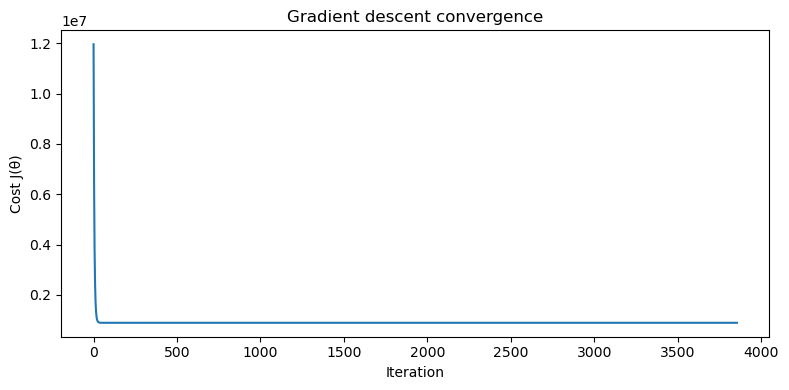

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(θ)")
plt.title("Gradient descent convergence")
plt.tight_layout()
plt.show()

# 2. Gradient Descent with PyTorch

In this section the same procedure will be repeated, but using the tools from the library PyTorch.

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [13]:
df = pd.read_csv("day.csv")

features = ["temp","atemp","hum","windspeed","holiday","season","workingday","weathersit"]

The data type of float32 is explicitly asked for, since that is the data type used by PyTorch tensors. Numpy will otherwise return a float64 object by default.

In [14]:
X_raw = df[features].values.astype(np.float32)
y_raw = df["cnt"].values.astype(np.float32)

In [15]:
np.random.seed(42)
idx   = np.random.permutation(len(y_raw))
split = int(0.8 * len(y_raw))
train_idx, test_idx = idx[:split], idx[split:]

In [16]:
X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
y_tr, y_te = y_raw[train_idx], y_raw[test_idx]

mu, std = X_tr.mean(0), X_tr.std(0)

X_tr = (X_tr - mu) / std
X_te = (X_te - mu) / std

So far everything has been the same. The data is imported and processed to be apt for training. The new tools will now be utilized. 

First, the data will be converted to PyTorch tensors. PyTorch has a built-in linear model in the function nn.Linear, which reproduces exactly $y = X\cdot\theta + b$. It should be noted that this function takes inputs and outputs as column vectors. That is, vectors of shape (N,1). So aside from converting the data to PyTorch tensors, the $y$ data will need to be unsqueezed. What the function unsqueeze(1) does is convert objects of shape (N,) (row vectors) to objects of shape (N,1) (column vectors).

In [17]:
y_train = torch.tensor(y_tr)
print(np.shape(y_train))

y_train = torch.tensor(y_tr).unsqueeze(1)
print(np.shape(y_train))


torch.Size([584])
torch.Size([584, 1])


with this in mind, the training and testing datasets will now be converted to PyTorch tensors.

In [18]:
X_train = torch.tensor(X_tr)
X_test = torch.tensor(X_te)
y_test = torch.tensor(y_te).unsqueeze(1)

Earlier when gradient descent was implemented using NumPy, the algorithm used the entire dataset in each step to update the gradient. This form of gradient descent is called batch gradient descent. PyTorch has built-in functions used to perform this procedure, but with the difference that they instead perform mini-batch gradient descents. This method uses a similar algorithm, but instead of utilizing the bulk of the dataset to compute the updated gradient, it splits it into multiple batches of smaller size and performs multiple updates of the gradient at the smaller data batches at once.

This method is particularly useful when working with very large datasets which would be too large for the computer's memory to handle. This is far from the case in this example, but it is a valuable method to learn.

This is implemented using the function DataLoader. One important argument of this function is the shuffle argument. Setting this as True makes it so the dataset is shuffled at each epoch of the algorithm, so that the model doesn't see batches in the same order at every step. This is so that the model doesn't develop a bias towards the order of the data. Seeing the same order epoch after epoch could cause the model to overfit towards that particular order.

In [19]:
train_ds = TensorDataset(X_train, y_train)      #pairs the tensors into a single dataset object.
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

Below, the linear model is implemented, indicating how many features and targets there are.

In [20]:
model = nn.Linear(8,1)

The cost function that was defined earlier is no more than a mean squared error function. PyTorch has this built in as well, as the function nn.MSELoss(), so it will be used from now on.

Instead of implementing gradient descent by hand, PyTorch has a function called torch.optim.SGD() which does this. This function needs to be passed the model's parameters and the learning rate (alpha). By passing it model.parameters(), it is given the weights and bias of the model defined in the previous line, and the same learning rate of 0.1 will continue to be used.

In [21]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

One full pass through a training dataset is called an 'epoch'. Below, 200 epochs are run to perform gradient descent on each of the mini-batches defined earlier in train_loader. For each iteration, the MSE is calculated by calling criterion, and then the optimizer is called to update the gradient. optimizer.zero_grad() clears all gradients, loss.backward() computes the new gradients, and optimizer.step() updates the weights in the model.

In [24]:
for epoch in range(200):
    model.train()
    for X_batch, y_batch in train_loader:
        pred = model(X_batch)          
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()         
        loss.backward()                
        optimizer.step()               

Now the model will be evaluated using the test set. It should be noted that torch.no_grad() is called here before anything else is done. This is because PyTorch performs gradient calculations even if the optimizer or criterion aren't ever called. It does so 'in preparation' for the likely loss.backward() call. Calling torch.no_grad() tells PyTorch to not bother computing any gradients for the upcoming lines.

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test).squeeze().numpy()
    y_true = y_test.squeeze().numpy()               #turns object of size (N,1) to (N,) and turns back to NumPy array.

rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"\nTest RMSE : {rmse:.2f}")
print(f"Test R²   : {r2:.4f}")


Test RMSE : 1418.69
Test R²   : 0.4859
